<a href="https://colab.research.google.com/github/faisu6339-glitch/Deep-Learning/blob/main/RNN_Character_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Objective

Train an RNN to learn the alphabet sequence.

Dataset
Input	Output
A B C	D
B C D	E
C D E	F
D E F	G
E F G	H
F G H	I
...	...
W X Y	Z

Later, we'll test:

X Y Z → ?

Expected Output

Next Character : Z (or no next character beyond Z in this toy example)

For a better prediction example, test:

M N O → P

In [1]:
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

np.random.seed(42)
tf.random.set_seed(42)

#Step 2: Create Alphabet Dataset

In [3]:
alphabet = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"

X = []
y = []

window_size = 3

for i in range(len(alphabet)-window_size):

    sequence = alphabet[i:i+window_size]

    target = alphabet[i+window_size]

    X.append(sequence)

    y.append(target)

print(X[:5])
print(y[:5])

['ABC', 'BCD', 'CDE', 'DEF', 'EFG']
['D', 'E', 'F', 'G', 'H']


#Step 3: Character Encoding

Convert characters into integers.

In [4]:
char_to_int = {
    c:i for i,c in enumerate(alphabet)
}

int_to_char = {
    i:c for i,c in enumerate(alphabet)
}

print(char_to_int)

{'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': 7, 'I': 8, 'J': 9, 'K': 10, 'L': 11, 'M': 12, 'N': 13, 'O': 14, 'P': 15, 'Q': 16, 'R': 17, 'S': 18, 'T': 19, 'U': 20, 'V': 21, 'W': 22, 'X': 23, 'Y': 24, 'Z': 25}


#Step 4: Convert Dataset to Numbers

In [5]:
X_encoded = []

for seq in X:

    X_encoded.append(
        [char_to_int[c] for c in seq]
    )

X_encoded = np.array(X_encoded)

y_encoded = np.array(
    [char_to_int[c] for c in y]
)
print(X_encoded[:5])
print(y_encoded)

[[0 1 2]
 [1 2 3]
 [2 3 4]
 [3 4 5]
 [4 5 6]]
[ 3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25]


ABC

↓

[0,1,2]

↓

Target

D

↓

3

#Step 5: Normalize

In [6]:
X_encoded = X_encoded / 25

y_encoded = y_encoded / 25

#Step 6: Reshape

In [7]:
X_encoded = X_encoded.reshape(
    (
        X_encoded.shape[0],
        X_encoded.shape[1],
        1
    )
)

print(X_encoded.shape)

(23, 3, 1)


#Step 7: Build RNN

In [8]:
model = Sequential([

    SimpleRNN(
        64,
        activation="tanh",
        input_shape=(3,1)
    ),

    Dense(
        32,
        activation="relu"
    ),

    Dense(1)

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


#Step 8: Compile

In [9]:
model.compile(

    optimizer="adam",

    loss="mse",

    metrics=["mae"]

)

In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,337 (24.75 KB)

 Trainable params: 6,337 (24.75 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history = model.fit(

    X_encoded,

    y_encoded,

    epochs=1000,

    verbose=0
)

In [12]:
test = np.array([
    [
        char_to_int["M"],
        char_to_int["N"],
        char_to_int["O"]
    ]
])

test = test / 25

test = test.reshape((1,3,1))

prediction = model.predict(test)

predicted_index = int(
    round(prediction[0][0]*25)
)

print(
    "Predicted Character :",
    int_to_char[predicted_index]
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
Predicted Character : P


In [13]:
tests = [

    "ABC",

    "DEF",

    "JKL",

    "QRS",

    "TUV"

]

for word in tests:

    sample = np.array([
        [char_to_int[c] for c in word]
    ])

    sample = sample / 25

    sample = sample.reshape((1,3,1))

    prediction = model.predict(sample,verbose=0)

    index = int(round(prediction[0][0]*25))

    print(
        word,
        "->",
        int_to_char[index]
    )

ABC -> D
DEF -> G
JKL -> M
QRS -> T
TUV -> W


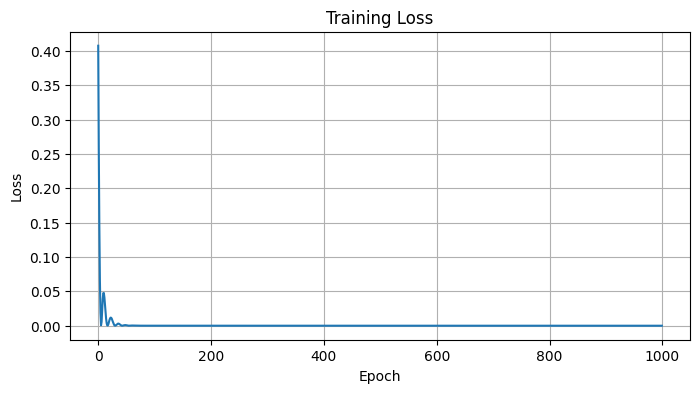

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.plot(history.history["loss"])

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.show()